# Train LightGBM Cold-start User v1 Fixed Sample10M bằng memmap

Notebook này dùng cho bảng/export:

`gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/*.parquet`

Mục tiêu:
- Load Parquet từ GCS về Colab.
- Convert dữ liệu sang `numpy.memmap` để tránh tràn RAM.
- Train LightGBM CPU ổn định trên Google Colab.
- Đo thời gian từng bước: download, tạo memmap, train, predict/evaluate.
- Lưu model, metrics, feature importance, prediction sample, biểu đồ lên Google Drive để demo và so sánh với ALS/LGBM v1/v2.

Lưu ý: bảng này là bản cold-start user đã sửa leak theo seed/holdout split. Không dùng trực tiếp target positive trong user seed profile.

## 0. Kiểm tra GPU/CPU/RAM Colab

In [1]:
import os, sys, platform, subprocess, json, time

print("Python:", sys.version)
print("Platform:", platform.platform())
print("CPU count:", os.cpu_count())

try:
    import psutil
    print("RAM:", psutil.virtual_memory())
except Exception as e:
    print("psutil chưa có:", e)

!nvidia-smi || true

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CPU count: 2
RAM: svmem(total=13605830656, available=12677410816, percent=6.8, used=635330560, free=9774469120, active=458534912, inactive=3177807872, buffers=135704576, cached=3060326400, shared=2068480, slab=126427136)
/bin/bash: line 1: nvidia-smi: command not found


## 1. Cài thư viện

In [2]:
!pip -q install lightgbm pyarrow pandas numpy scikit-learn joblib psutil google-cloud-storage matplotlib

## 2. Mount Google Drive và xác thực GCP

In [3]:
from google.colab import drive, auth

drive.mount("/content/drive")
auth.authenticate_user()

PROJECT_ID = "project-79499e5c-69d7-42b8-864"
BUCKET = "truong_bigdata_24032026_init"

# Bản sample10m đã export từ BigQuery sang GCS
GCS_PARQUET_PATH = "gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/*.parquet"

!gcloud config set project {PROJECT_ID}
print("GCS_PARQUET_PATH =", GCS_PARQUET_PATH)

Mounted at /content/drive
[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
GCS_PARQUET_PATH = gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/*.parquet


## 3. Tạo thư mục output

Tất cả kết quả cuối cùng sẽ nằm trong Google Drive:

`/content/drive/MyDrive/steam_recommender_outputs/...`

In [4]:
import os
from datetime import datetime

RUN_NAME = "cold_start_lgbm_fixed_v1_sample10m_cpu_memmap"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

DRIVE_ROOT = "/content/drive/MyDrive/steam_recommender_outputs"
DRIVE_OUT_DIR = f"{DRIVE_ROOT}/{RUN_NAME}_{TIMESTAMP}"
LOCAL_DATA_DIR = "/content/cold_start_user_v1_fixed_sample10m"
MEMMAP_DIR = "/content/memmap_cold_start_fixed_sample10m"
PLOT_DIR = os.path.join(DRIVE_OUT_DIR, "plots")

for d in [DRIVE_ROOT, DRIVE_OUT_DIR, LOCAL_DATA_DIR, MEMMAP_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive output:", DRIVE_OUT_DIR)
print("Local data:", LOCAL_DATA_DIR)
print("Memmap dir:", MEMMAP_DIR)
print("Plot dir:", PLOT_DIR)

Drive output: /content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009
Local data: /content/cold_start_user_v1_fixed_sample10m
Memmap dir: /content/memmap_cold_start_fixed_sample10m
Plot dir: /content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009/plots


## 4. Download Parquet từ GCS về Colab

Nếu cell này lỗi permission, kiểm tra account Google đang dùng trong Colab có quyền đọc bucket GCS không.

In [5]:
import time, os, glob

timing = {}

download_start = time.time()

# Xóa file cũ nếu có
!rm -f "{LOCAL_DATA_DIR}"/*.parquet

!gsutil -m cp "{GCS_PARQUET_PATH}" "{LOCAL_DATA_DIR}/"

download_time = time.time() - download_start
timing["download_seconds"] = download_time
print(f"Download finished in {download_time/60:.2f} minutes")

parquet_files = sorted(glob.glob(os.path.join(LOCAL_DATA_DIR, "*.parquet")))
print("Number of parquet files:", len(parquet_files))
for f in parquet_files[:10]:
    print(os.path.basename(f), round(os.path.getsize(f) / 1024 / 1024, 2), "MB")
assert len(parquet_files) > 0, "Không tìm thấy file parquet. Kiểm tra lại GCS path."

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000000.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000001.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000005.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000002.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000003.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_v1_fixed_sample10m/000000000004.parquet...
Copying gs://truong_bigdata_24032026_init/steam/gold/cold_start_user_

## 5. Đọc schema và chọn feature

Notebook tự động loại `user_id`, `app_id`, `label`, `split`. Các cột còn lại là feature numeric để train.

In [8]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

sample_pf = pq.ParquetFile(parquet_files[0])
schema_names = sample_pf.schema.names

print("Columns:")
print(schema_names)

id_cols = ["user_id", "app_id"]
label_col = "label"
split_col = "split"
exclude_cols = id_cols + [label_col, split_col]

feature_cols = [c for c in schema_names if c not in exclude_cols]

print("\nFeature count:", len(feature_cols))
for i, c in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {c}")

assert label_col in schema_names, "Thiếu cột label"
assert split_col in schema_names, "Thiếu cột split"
assert "user_id" in schema_names and "app_id" in schema_names, "Thiếu user_id/app_id"
assert len(feature_cols) > 0, "Không có feature nào để train"

Columns:
['user_id', 'app_id', 'label', 'split', 'seed_game_count', 'user_avg_days_since_release', 'user_pref_win', 'user_pref_mac', 'user_pref_linux', 'user_avg_platform_count', 'user_pref_cross_platform', 'user_avg_platform_score', 'user_pref_steam_deck', 'user_avg_steam_deck_score', 'user_avg_rating', 'user_avg_positive_ratio', 'user_avg_seed_app_log_user_count', 'user_avg_seed_novelty_score', 'user_seed_interaction_sum', 'user_seed_interaction_avg', 'days_since_release', 'win', 'mac', 'linux', 'platform_count', 'is_cross_platform', 'platform_score', 'steam_deck', 'steam_deck_score', 'rating', 'positive_ratio', 'app_interaction_count', 'app_user_count', 'app_log_interaction_count', 'app_log_user_count', 'app_novelty_score', 'user_quality_x_game_quality', 'user_positive_ratio_x_game_positive_ratio', 'user_popularity_x_game_popularity', 'user_novelty_x_game_novelty', 'user_win_x_game_win', 'user_mac_x_game_mac', 'user_linux_x_game_linux', 'user_steamdeck_x_game_steamdeck']

Feature co

## 6. Đếm train/valid rows trước khi tạo memmap

In [9]:
import pyarrow.parquet as pq
import time

BATCH_SIZE = 100_000

count_start = time.time()

train_rows = 0
valid_rows = 0
total_rows = 0
pos_train = 0
pos_valid = 0

for path_idx, path in enumerate(parquet_files, start=1):
    pf = pq.ParquetFile(path)
    for batch in pf.iter_batches(batch_size=BATCH_SIZE, columns=[split_col, label_col]):
        pdf = batch.to_pandas()
        train_mask = pdf[split_col].eq("train")
        valid_mask = pdf[split_col].eq("valid")
        train_rows += int(train_mask.sum())
        valid_rows += int(valid_mask.sum())
        total_rows += len(pdf)
        pos_train += int(pdf.loc[train_mask, label_col].sum())
        pos_valid += int(pdf.loc[valid_mask, label_col].sum())
    print(f"Counted file {path_idx}/{len(parquet_files)}")

count_time = time.time() - count_start
timing["count_rows_seconds"] = count_time

print("Total rows:", f"{total_rows:,}")
print("Train rows:", f"{train_rows:,}")
print("Valid rows:", f"{valid_rows:,}")
print("Train positives:", f"{pos_train:,}")
print("Valid positives:", f"{pos_valid:,}")
print("Train positive rate:", pos_train / max(train_rows, 1))
print("Valid positive rate:", pos_valid / max(valid_rows, 1))
print(f"Counting time: {count_time/60:.2f} minutes")

assert train_rows > 0 and valid_rows > 0, "Train/valid rows không hợp lệ"

Counted file 1/204
Counted file 2/204
Counted file 3/204
Counted file 4/204
Counted file 5/204
Counted file 6/204
Counted file 7/204
Counted file 8/204
Counted file 9/204
Counted file 10/204
Counted file 11/204
Counted file 12/204
Counted file 13/204
Counted file 14/204
Counted file 15/204
Counted file 16/204
Counted file 17/204
Counted file 18/204
Counted file 19/204
Counted file 20/204
Counted file 21/204
Counted file 22/204
Counted file 23/204
Counted file 24/204
Counted file 25/204
Counted file 26/204
Counted file 27/204
Counted file 28/204
Counted file 29/204
Counted file 30/204
Counted file 31/204
Counted file 32/204
Counted file 33/204
Counted file 34/204
Counted file 35/204
Counted file 36/204
Counted file 37/204
Counted file 38/204
Counted file 39/204
Counted file 40/204
Counted file 41/204
Counted file 42/204
Counted file 43/204
Counted file 44/204
Counted file 45/204
Counted file 46/204
Counted file 47/204
Counted file 48/204
Counted file 49/204
Counted file 50/204
Counted f

## 7. Tạo memmap X/y/user_id/app_id

In [10]:
import numpy as np
import os

n_features = len(feature_cols)

X_train_path = os.path.join(MEMMAP_DIR, "X_train.float32.memmap")
y_train_path = os.path.join(MEMMAP_DIR, "y_train.int8.memmap")

X_valid_path = os.path.join(MEMMAP_DIR, "X_valid.float32.memmap")
y_valid_path = os.path.join(MEMMAP_DIR, "y_valid.int8.memmap")

valid_user_path = os.path.join(MEMMAP_DIR, "valid_user_id.int64.memmap")
valid_app_path = os.path.join(MEMMAP_DIR, "valid_app_id.int64.memmap")

# Xóa memmap cũ nếu có để tránh lỗi shape cũ
for p in [X_train_path, y_train_path, X_valid_path, y_valid_path, valid_user_path, valid_app_path]:
    if os.path.exists(p):
        os.remove(p)

X_train = np.memmap(X_train_path, dtype="float32", mode="w+", shape=(train_rows, n_features))
y_train = np.memmap(y_train_path, dtype="int8", mode="w+", shape=(train_rows,))

X_valid = np.memmap(X_valid_path, dtype="float32", mode="w+", shape=(valid_rows, n_features))
y_valid = np.memmap(y_valid_path, dtype="int8", mode="w+", shape=(valid_rows,))

valid_user_id = np.memmap(valid_user_path, dtype="int64", mode="w+", shape=(valid_rows,))
valid_app_id = np.memmap(valid_app_path, dtype="int64", mode="w+", shape=(valid_rows,))

print("Memmap created.")
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Estimated X_train size GB:", X_train.size * 4 / 1024**3)
print("Estimated X_valid size GB:", X_valid.size * 4 / 1024**3)

Memmap created.
X_train shape: (19276496, 40)
X_valid shape: (2138694, 40)
Estimated X_train size GB: 2.8724217414855957
Estimated X_valid size GB: 0.3186902403831482


## 8. Ghi dữ liệu vào memmap theo batch

Cell này là bước quan trọng để tránh `pd.read_parquet` load toàn bộ dữ liệu vào RAM.

In [11]:
import gc
import time
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

write_start = time.time()

train_pos_cursor = 0
valid_pos_cursor = 0
cols_to_read = id_cols + [label_col, split_col] + feature_cols

for path_idx, path in enumerate(parquet_files, start=1):
    pf = pq.ParquetFile(path)
    batch_idx = 0
    for batch in pf.iter_batches(batch_size=BATCH_SIZE, columns=cols_to_read):
        batch_idx += 1
        pdf = batch.to_pandas()

        # Feature numeric: xử lý inf/null rồi ép float32
        X_batch = (
            pdf[feature_cols]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
            .astype("float32")
            .values
        )

        y_batch = pdf[label_col].fillna(0).astype("int8").values

        train_mask = pdf[split_col].eq("train").values
        valid_mask = pdf[split_col].eq("valid").values

        n_tr = int(train_mask.sum())
        n_va = int(valid_mask.sum())

        if n_tr > 0:
            X_train[train_pos_cursor:train_pos_cursor+n_tr, :] = X_batch[train_mask]
            y_train[train_pos_cursor:train_pos_cursor+n_tr] = y_batch[train_mask]
            train_pos_cursor += n_tr

        if n_va > 0:
            X_valid[valid_pos_cursor:valid_pos_cursor+n_va, :] = X_batch[valid_mask]
            y_valid[valid_pos_cursor:valid_pos_cursor+n_va] = y_batch[valid_mask]
            valid_user_id[valid_pos_cursor:valid_pos_cursor+n_va] = pdf.loc[valid_mask, "user_id"].astype("int64").values
            valid_app_id[valid_pos_cursor:valid_pos_cursor+n_va] = pdf.loc[valid_mask, "app_id"].astype("int64").values
            valid_pos_cursor += n_va

        del pdf, X_batch, y_batch, train_mask, valid_mask
        gc.collect()

    X_train.flush(); y_train.flush(); X_valid.flush(); y_valid.flush(); valid_user_id.flush(); valid_app_id.flush()
    print(f"Processed file {path_idx}/{len(parquet_files)} | train_cursor={train_pos_cursor:,} | valid_cursor={valid_pos_cursor:,}")

write_time = time.time() - write_start
timing["write_memmap_seconds"] = write_time

print("Finished writing memmap.")
print("train_pos_cursor:", train_pos_cursor, "expected:", train_rows)
print("valid_pos_cursor:", valid_pos_cursor, "expected:", valid_rows)
print(f"Memmap writing time: {write_time/60:.2f} minutes")

assert train_pos_cursor == train_rows, "Sai số dòng train khi ghi memmap"
assert valid_pos_cursor == valid_rows, "Sai số dòng valid khi ghi memmap"

Processed file 1/204 | train_cursor=94,427 | valid_cursor=10,679
Processed file 2/204 | train_cursor=188,548 | valid_cursor=21,226
Processed file 3/204 | train_cursor=282,751 | valid_cursor=31,647
Processed file 4/204 | train_cursor=377,521 | valid_cursor=41,999
Processed file 5/204 | train_cursor=472,147 | valid_cursor=52,541
Processed file 6/204 | train_cursor=566,642 | valid_cursor=62,815
Processed file 7/204 | train_cursor=660,906 | valid_cursor=73,042
Processed file 8/204 | train_cursor=754,973 | valid_cursor=83,366
Processed file 9/204 | train_cursor=849,369 | valid_cursor=93,613
Processed file 10/204 | train_cursor=944,076 | valid_cursor=104,118
Processed file 11/204 | train_cursor=1,038,944 | valid_cursor=114,696
Processed file 12/204 | train_cursor=1,134,167 | valid_cursor=125,183
Processed file 13/204 | train_cursor=1,228,843 | valid_cursor=135,615
Processed file 14/204 | train_cursor=1,322,845 | valid_cursor=146,201
Processed file 15/204 | train_cursor=1,417,346 | valid_curs

## 9. Reload memmap dạng read-only

In [12]:
X_train = np.memmap(X_train_path, dtype="float32", mode="r", shape=(train_rows, n_features))
y_train = np.memmap(y_train_path, dtype="int8", mode="r", shape=(train_rows,))

X_valid = np.memmap(X_valid_path, dtype="float32", mode="r", shape=(valid_rows, n_features))
y_valid = np.memmap(y_valid_path, dtype="int8", mode="r", shape=(valid_rows,))

valid_user_id = np.memmap(valid_user_path, dtype="int64", mode="r", shape=(valid_rows,))
valid_app_id = np.memmap(valid_app_path, dtype="int64", mode="r", shape=(valid_rows,))

print("Reloaded memmaps.")
print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_valid:", X_valid.shape, X_valid.dtype)
print("y_valid:", y_valid.shape, y_valid.dtype)
print("Train positive rate:", float(np.mean(y_train)))
print("Valid positive rate:", float(np.mean(y_valid)))

Reloaded memmaps.
X_train: (19276496, 40) float32
y_train: (19276496,) int8
X_valid: (2138694, 40) float32
y_valid: (2138694,) int8
Train positive rate: 0.317279862481231
Valid positive rate: 0.31721321516776124


## 10. Train LightGBM CPU có đo thời gian

Cấu hình này ưu tiên ổn định cho Colab. Nếu muốn train nhanh hơn, giảm `num_boost_round` xuống 300 hoặc tăng `learning_rate` lên 0.07.

In [13]:
import lightgbm as lgb
import time
import psutil
import os

num_pos = int(y_train.sum())
num_neg = int(len(y_train) - num_pos)
scale_pos_weight = num_neg / max(num_pos, 1)

print("Train rows:", f"{len(y_train):,}")
print("Valid rows:", f"{len(y_valid):,}")
print("num_pos:", f"{num_pos:,}")
print("num_neg:", f"{num_neg:,}")
print("scale_pos_weight:", scale_pos_weight)
print("Feature count:", n_features)
print("RAM before train:", psutil.virtual_memory())

construct_start = time.time()

train_set = lgb.Dataset(
    X_train,
    label=y_train,
    feature_name=feature_cols,
    free_raw_data=False
)

valid_set = lgb.Dataset(
    X_valid,
    label=y_valid,
    feature_name=feature_cols,
    reference=train_set,
    free_raw_data=False
)

construct_time = time.time() - construct_start
timing["construct_dataset_seconds"] = construct_time
print(f"LightGBM Dataset created in {construct_time/60:.2f} minutes")

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision", "binary_logloss"],
    "boosting_type": "gbdt",

    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 200,

    "feature_fraction": 0.85,
    "bagging_fraction": 0.85,
    "bagging_freq": 1,

    "scale_pos_weight": scale_pos_weight,

    "num_threads": max(os.cpu_count() - 1, 1),
    "verbose": -1,
    "seed": 42,
    "force_col_wise": True
}

train_start = time.time()

model = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(period=25)
    ]
)

train_time = time.time() - train_start
timing["train_seconds"] = train_time

print(f"Training finished in {train_time/60:.2f} minutes")
print("Best iteration:", model.best_iteration)
print("RAM after train:", psutil.virtual_memory())

Train rows: 19,276,496
Valid rows: 2,138,694
num_pos: 6,116,044
num_neg: 13,160,452
scale_pos_weight: 2.151791582925172
Feature count: 40
RAM before train: svmem(total=13605830656, available=11817754624, percent=13.1, used=1452236800, free=264462336, active=1172422656, inactive=11644153856, buffers=164233216, cached=11724898304, shared=2281472, slab=423124992)
LightGBM Dataset created in 0.00 minutes
Training until validation scores don't improve for 30 rounds
[25]	train's auc: 0.942431	train's average_precision: 0.893179	train's binary_logloss: 0.342439	valid's auc: 0.942176	valid's average_precision: 0.892892	valid's binary_logloss: 0.342652
[50]	train's auc: 0.94299	train's average_precision: 0.89464	train's binary_logloss: 0.306524	valid's auc: 0.942721	valid's average_precision: 0.894313	valid's binary_logloss: 0.306804
[75]	train's auc: 0.943814	train's average_precision: 0.896733	train's binary_logloss: 0.300945	valid's auc: 0.943535	valid's average_precision: 0.896364	valid's b

## 11. Đánh giá classification metrics

In [15]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)
import numpy as np
import pandas as pd
import time

pred_start = time.time()
valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)
pred_time = time.time() - pred_start
timing["prediction_seconds"] = pred_time

auc = roc_auc_score(y_valid, valid_pred)
ap = average_precision_score(y_valid, valid_pred)
ll = log_loss(y_valid, np.clip(valid_pred, 1e-7, 1 - 1e-7))

threshold = 0.5
valid_pred_label = (valid_pred >= threshold).astype("int8")

precision = precision_score(y_valid, valid_pred_label, zero_division=0)
recall = recall_score(y_valid, valid_pred_label, zero_division=0)
f1 = f1_score(y_valid, valid_pred_label, zero_division=0)
acc = accuracy_score(y_valid, valid_pred_label)
cm = confusion_matrix(y_valid, valid_pred_label)

classification_metrics = {
    "model_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "train_rows": int(train_rows),
    "valid_rows": int(valid_rows),
    "feature_count": int(n_features),
    "positive_train": int(num_pos),
    "negative_train": int(num_neg),
    "positive_rate_train": float(np.mean(y_train)),
    "positive_rate_valid": float(np.mean(y_valid)),
    "scale_pos_weight": float(scale_pos_weight),
    "best_iteration": int(model.best_iteration),
    "auc": float(auc),
    "average_precision": float(ap),
    "binary_logloss": float(ll),
    "precision_at_0_5": float(precision),
    "recall_at_0_5": float(recall),
    "f1_at_0_5": float(f1),
    "accuracy_at_0_5": float(acc),
    "download_time_minutes": float(timing.get("download_seconds", 0) / 60),
    "count_rows_time_minutes": float(timing.get("count_rows_seconds", 0) / 60),
    "write_memmap_time_minutes": float(timing.get("write_memmap_seconds", 0) / 60),
    "construct_dataset_time_minutes": float(timing.get("construct_dataset_seconds", 0) / 60),
    "train_time_minutes": float(timing.get("train_seconds", 0) / 60),
    "prediction_time_minutes": float(timing.get("prediction_seconds", 0) / 60),
}

print("AUC:", auc)
print("Average Precision:", ap)
print("Logloss:", ll)
print("Precision@0.5:", precision)
print("Recall@0.5:", recall)
print("F1@0.5:", f1)
print("Accuracy@0.5:", acc)
print("Confusion matrix:", cm)

pd.DataFrame([classification_metrics])

AUC: 0.9472310387685182
Average Precision: 0.9035240686126838
Logloss: 0.292208646998514
Precision@0.5: 0.7717887080067807
Recall@0.5: 0.8764500561597354
F1@0.5: 0.8207964418529531
Accuracy@0.5: 0.8785997435818308
Confusion matrix: [[1284453  175819]
 [  83819  594603]]


,model_name,timestamp,train_rows,valid_rows,feature_count,positive_train,negative_train,positive_rate_train,positive_rate_valid,scale_pos_weight,...,precision_at_0_5,recall_at_0_5,f1_at_0_5,accuracy_at_0_5,download_time_minutes,count_rows_time_minutes,write_memmap_time_minutes,construct_dataset_time_minutes,train_time_minutes,prediction_time_minutes
0,cold_start_lgbm_fixed_v1_sample10m_cpu_memmap,20260529_114009,19276496,2138694,40,6116044,13160452,0.31728,0.317213,2.151792,...,0.771789,0.87645,0.820796,0.8786,1.300772,0.159829,1.64508,0.000003,152.714961,1.009701


## 12. Ranking metrics Recall@K / NDCG@K

Vì recommendation cần xếp hạng top game cho user, Recall@K và NDCG@K quan trọng hơn accuracy.

In [16]:
import pandas as pd
import numpy as np
import math
import time

rank_start = time.time()

valid_rank_df = pd.DataFrame({
    "user_id": np.asarray(valid_user_id),
    "app_id": np.asarray(valid_app_id),
    "label": np.asarray(y_valid),
    "score": valid_pred.astype("float32")
})

valid_rank_df = valid_rank_df.sort_values(["user_id", "score"], ascending=[True, False])
valid_rank_df["rank"] = valid_rank_df.groupby("user_id").cumcount() + 1

# Chỉ evaluate user có ít nhất 1 positive trong valid
total_pos_by_user = valid_rank_df.groupby("user_id")["label"].sum()
valid_eval_users = total_pos_by_user[total_pos_by_user > 0].index
valid_eval_df = valid_rank_df[valid_rank_df["user_id"].isin(valid_eval_users)].copy()

print("Valid users:", valid_rank_df["user_id"].nunique())
print("Eval users with positive:", len(valid_eval_users))

ranking_metrics = {}

for k in [5, 10, 20, 50]:
    topk = valid_eval_df[valid_eval_df["rank"] <= k]
    hits = topk.groupby("user_id")["label"].sum()
    total_pos = valid_eval_df.groupby("user_id")["label"].sum()
    recall_user = hits.reindex(total_pos.index).fillna(0) / total_pos
    ranking_metrics[f"recall_at_{k}"] = float(recall_user.mean())

    # NDCG@K
    ndcg_scores = []
    for _, g in valid_eval_df.groupby("user_id", sort=False):
        labels = g.sort_values("rank")["label"].values[:k]
        dcg = 0.0
        for i, rel in enumerate(labels):
            if rel > 0:
                dcg += 1.0 / math.log2(i + 2)
        ideal_hits = int(min(g["label"].sum(), k))
        if ideal_hits > 0:
            idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal_hits))
            ndcg_scores.append(dcg / idcg)
    ranking_metrics[f"ndcg_at_{k}"] = float(np.mean(ndcg_scores)) if ndcg_scores else 0.0

rank_time = time.time() - rank_start
timing["ranking_eval_seconds"] = rank_time
ranking_metrics["ranking_eval_time_minutes"] = float(rank_time / 60)

pd.DataFrame([ranking_metrics])

Valid users: 390962
Eval users with positive: 390962


,recall_at_5,ndcg_at_5,recall_at_10,ndcg_at_10,recall_at_20,ndcg_at_20,recall_at_50,ndcg_at_50,ranking_eval_time_minutes
0,0.995947,0.956981,1.0,0.958751,1.0,0.958751,1.0,0.958751,7.626963


## 13. Baseline để so sánh với mô hình khác

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
import pandas as pd
import numpy as np

baseline_rows = []

def evaluate_score_array(name, score):
    score = np.asarray(score, dtype="float64")
    s_min = np.nanmin(score)
    s_max = np.nanmax(score)
    if s_max > s_min:
        prob = (score - s_min) / (s_max - s_min)
    else:
        prob = np.full_like(score, 0.5)
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    baseline_rows.append({
        "model_name": name,
        "auc": float(roc_auc_score(y_valid, prob)),
        "average_precision": float(average_precision_score(y_valid, prob)),
        "binary_logloss": float(log_loss(y_valid, prob))
    })

# LightGBM
evaluate_score_array("LightGBM_cold_start_sample10m", valid_pred)

feature_index = {c: i for i, c in enumerate(feature_cols)}

for col in [
    "app_log_user_count",
    "rating",
    "positive_ratio",
    "app_novelty_score",
    "user_quality_x_game_quality",
    "user_positive_ratio_x_game_positive_ratio",
    "user_popularity_x_game_popularity",
    "user_novelty_x_game_novelty",
    "user_win_x_game_win",
    "user_steamdeck_x_game_steamdeck"
]:
    if col in feature_index:
        evaluate_score_array(f"baseline_{col}", X_valid[:, feature_index[col]])

baseline_compare_df = pd.DataFrame(baseline_rows).sort_values("auc", ascending=False)
baseline_compare_df

,model_name,auc,average_precision,binary_logloss
0,LightGBM_cold_start_sample10m,0.947231,0.903524,0.291801
1,baseline_app_log_user_count,0.936229,0.890016,0.474213
7,baseline_user_popularity_x_game_popularity,0.897192,0.840024,0.469814
3,baseline_positive_ratio,0.652454,0.432082,1.340301
6,baseline_user_positive_ratio_x_game_positive_r...,0.631905,0.433620,0.948580
9,baseline_user_win_x_game_win,0.501936,0.318054,9.371724
2,baseline_rating,0.500000,0.317213,0.693147
5,baseline_user_quality_x_game_quality,0.500000,0.317213,0.693147
10,baseline_user_steamdeck_x_game_steamdeck,0.499975,0.317202,9.428749
8,baseline_user_novelty_x_game_novelty,0.109568,0.187465,1.155849


## 14. Feature importance

In [18]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_gain": model.feature_importance(importance_type="gain"),
    "importance_split": model.feature_importance(importance_type="split")
})
importance_df = importance_df.sort_values("importance_gain", ascending=False)
display(importance_df.head(50))

,feature,importance_gain,importance_split
27,app_interaction_count,8.550190e+07,1557
31,app_novelty_score,7.167724e+07,1100
29,app_log_interaction_count,6.461312e+06,32
28,app_user_count,5.335741e+06,202
13,user_avg_seed_novelty_score,2.737499e+06,979
12,user_avg_seed_app_log_user_count,2.300644e+06,1273
1,user_avg_days_since_release,2.194855e+06,1848
16,days_since_release,1.282059e+06,2309
33,user_positive_ratio_x_game_positive_ratio,5.247210e+05,760
26,positive_ratio,3.660706e+05,1060


## 15. Vẽ biểu đồ và lưu vào Drive

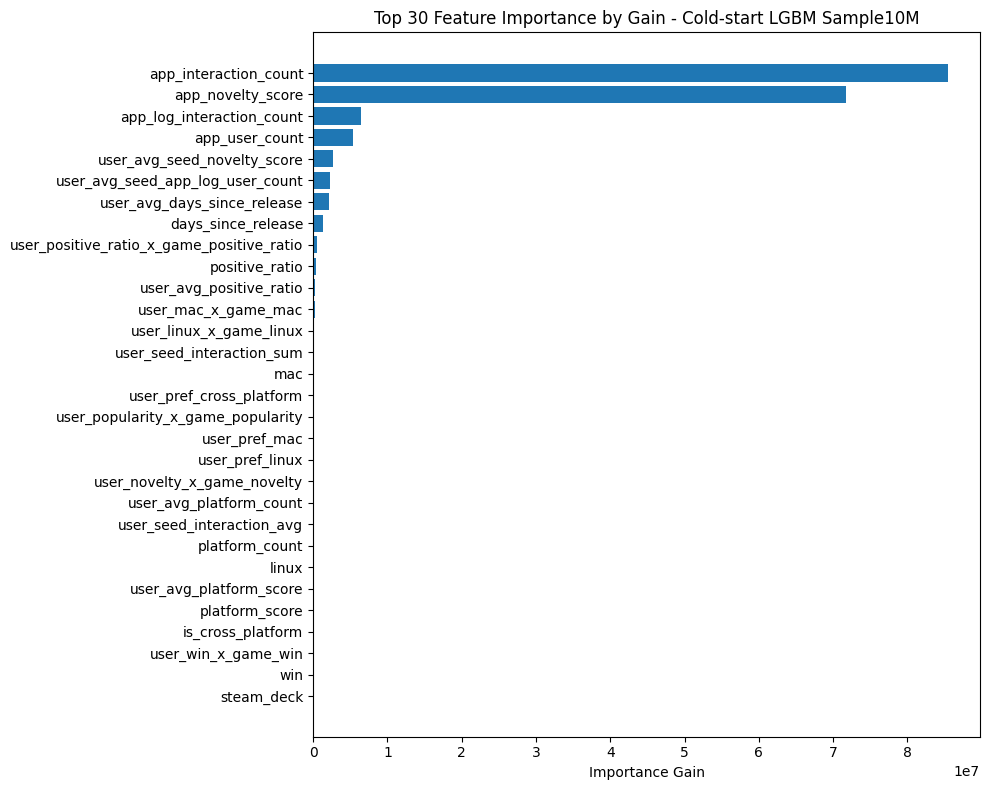

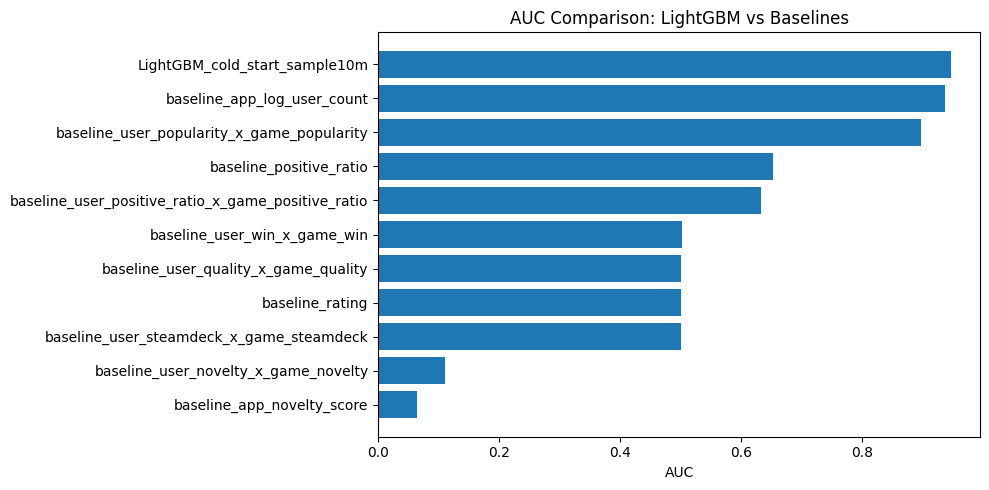

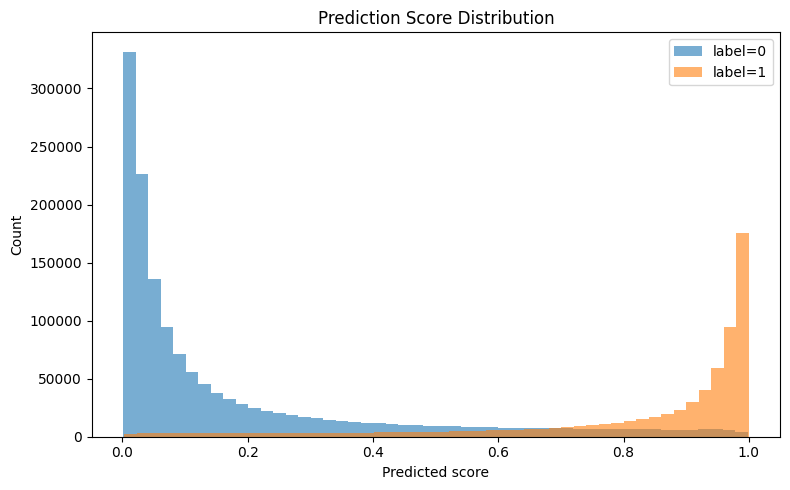

Saved plots:
/content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009/plots/feature_importance_top30.png
/content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009/plots/baseline_auc_comparison.png
/content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009/plots/prediction_score_distribution.png


In [19]:
import matplotlib.pyplot as plt
import os

# 1. Feature importance top 30
plt.figure(figsize=(10, 8))
top_imp = importance_df.head(30).sort_values("importance_gain")
plt.barh(top_imp["feature"], top_imp["importance_gain"])
plt.title("Top 30 Feature Importance by Gain - Cold-start LGBM Sample10M")
plt.xlabel("Importance Gain")
plt.tight_layout()
feature_plot_path = os.path.join(PLOT_DIR, "feature_importance_top30.png")
plt.savefig(feature_plot_path, dpi=150)
plt.show()

# 2. Model comparison AUC/AP
plt.figure(figsize=(10, 5))
plot_df = baseline_compare_df.sort_values("auc", ascending=True)
plt.barh(plot_df["model_name"], plot_df["auc"])
plt.title("AUC Comparison: LightGBM vs Baselines")
plt.xlabel("AUC")
plt.tight_layout()
auc_plot_path = os.path.join(PLOT_DIR, "baseline_auc_comparison.png")
plt.savefig(auc_plot_path, dpi=150)
plt.show()

# 3. Prediction distribution
plt.figure(figsize=(8, 5))
plt.hist(valid_pred[y_valid == 0], bins=50, alpha=0.6, label="label=0")
plt.hist(valid_pred[y_valid == 1], bins=50, alpha=0.6, label="label=1")
plt.title("Prediction Score Distribution")
plt.xlabel("Predicted score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
pred_dist_path = os.path.join(PLOT_DIR, "prediction_score_distribution.png")
plt.savefig(pred_dist_path, dpi=150)
plt.show()

print("Saved plots:")
print(feature_plot_path)
print(auc_plot_path)
print(pred_dist_path)

## 16. Lưu model, metrics, importance, predictions lên Google Drive

In [22]:
import json
import joblib
import os
import pandas as pd

model_txt_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_model.txt")
model_pkl_path = os.path.join(DRIVE_OUT_DIR, "lightgbm_model.pkl")
metrics_json_path = os.path.join(DRIVE_OUT_DIR, "classification_metrics.json")
metrics_csv_path = os.path.join(DRIVE_OUT_DIR, "classification_metrics.csv")
ranking_csv_path = os.path.join(DRIVE_OUT_DIR, "ranking_metrics.csv")
baseline_csv_path = os.path.join(DRIVE_OUT_DIR, "baseline_comparison.csv")
importance_csv_path = os.path.join(DRIVE_OUT_DIR, "feature_importance.csv")
feature_list_path = os.path.join(DRIVE_OUT_DIR, "feature_cols.json")
timing_json_path = os.path.join(DRIVE_OUT_DIR, "timing.json")
valid_pred_sample_path = os.path.join(DRIVE_OUT_DIR, "valid_prediction_sample.csv")
demo_topk_path = os.path.join(DRIVE_OUT_DIR, "demo_topk_recommendations.csv")

# Save model
model.save_model(model_txt_path)
joblib.dump(model, model_pkl_path)

# Save metrics
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(classification_metrics, f, indent=2, ensure_ascii=False)

pd.DataFrame([classification_metrics]).to_csv(metrics_csv_path, index=False)
pd.DataFrame([ranking_metrics]).to_csv(ranking_csv_path, index=False)
baseline_compare_df.to_csv(baseline_csv_path, index=False)
importance_df.to_csv(importance_csv_path, index=False)

with open(feature_list_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2, ensure_ascii=False)

with open(timing_json_path, "w", encoding="utf-8") as f:
    json.dump(timing, f, indent=2, ensure_ascii=False)

# Save prediction sample for demo
valid_sample_df = valid_rank_df.sample(
    n=min(200_000, len(valid_rank_df)),
    random_state=42
)
valid_sample_df.to_csv(valid_pred_sample_path, index=False)

# Demo top 10 per valid user, giới hạn để file không quá lớn
# Lấy top10 của tối đa 50k user đầu tiên để demo
sample_users = valid_rank_df["user_id"].drop_duplicates().head(50_000)

demo_topk_df = valid_rank_df[
    (valid_rank_df["user_id"].isin(sample_users)) &
    (valid_rank_df["rank"] <= 10)
].sort_values(["user_id", "rank"])

demo_topk_df.to_csv(demo_topk_path, index=False)

print("Saved all outputs to:")
print(DRIVE_OUT_DIR)

print("\nFiles:")
for root, dirs, files in os.walk(DRIVE_OUT_DIR):
    level = root.replace(DRIVE_OUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        file_path = os.path.join(root, f)
        size_mb = os.path.getsize(file_path) / 1024 / 1024
        print(f"{indent}  - {f} ({size_mb:.2f} MB)")

Saved all outputs to:
/content/drive/MyDrive/steam_recommender_outputs/cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009

Files:
cold_start_lgbm_fixed_v1_sample10m_cpu_memmap_20260529_114009/
  - lightgbm_model.txt (1.74 MB)
  - lightgbm_model.pkl (1.75 MB)
  - classification_metrics.json (0.00 MB)
  - classification_metrics.csv (0.00 MB)
  - ranking_metrics.csv (0.00 MB)
  - baseline_comparison.csv (0.00 MB)
  - feature_importance.csv (0.00 MB)
  - feature_cols.json (0.00 MB)
  - timing.json (0.00 MB)
  - valid_prediction_sample.csv (7.68 MB)
  - demo_topk_recommendations.csv (10.65 MB)
  plots/
    - feature_importance_top30.png (0.15 MB)
    - baseline_auc_comparison.png (0.08 MB)
    - prediction_score_distribution.png (0.04 MB)


## 17. Cập nhật file tổng hợp để so sánh với ALS/LGBM v1/v2/cold-start

File tổng hợp nằm ở:

`/content/drive/MyDrive/steam_recommender_outputs/model_comparison_summary.csv`

In [23]:
summary_compare_path = os.path.join(DRIVE_ROOT, "model_comparison_summary.csv")

current_summary = {
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_type": "LightGBM CPU memmap",
    "train_table_or_export": "gold_lgbm_train_cold_start_user_v1_fixed_sample10m",
    "gcs_path": GCS_PARQUET_PATH,
    "train_rows": int(train_rows),
    "valid_rows": int(valid_rows),
    "feature_count": int(n_features),
    "train_time_minutes": float(timing.get("train_seconds", 0) / 60),
    "total_pipeline_time_minutes": float(sum(timing.values()) / 60),
    "best_iteration": int(model.best_iteration),
    "auc": float(auc),
    "average_precision": float(ap),
    "binary_logloss": float(ll),
    "recall_at_5": ranking_metrics.get("recall_at_5"),
    "recall_at_10": ranking_metrics.get("recall_at_10"),
    "recall_at_20": ranking_metrics.get("recall_at_20"),
    "ndcg_at_5": ranking_metrics.get("ndcg_at_5"),
    "ndcg_at_10": ranking_metrics.get("ndcg_at_10"),
    "ndcg_at_20": ranking_metrics.get("ndcg_at_20"),
    "output_dir": DRIVE_OUT_DIR
}

current_summary_df = pd.DataFrame([current_summary])

if os.path.exists(summary_compare_path):
    old_df = pd.read_csv(summary_compare_path)
    new_df = pd.concat([old_df, current_summary_df], ignore_index=True)
else:
    new_df = current_summary_df

new_df.to_csv(summary_compare_path, index=False)

display(new_df.sort_values("auc", ascending=False))
print("Updated comparison file:")
print(summary_compare_path)

,run_name,timestamp,model_type,train_table_or_export,gcs_path,train_rows,valid_rows,feature_count,train_time_minutes,total_pipeline_time_minutes,...,auc,average_precision,binary_logloss,recall_at_5,recall_at_10,recall_at_20,ndcg_at_5,ndcg_at_10,ndcg_at_20,output_dir
0,cold_start_lgbm_fixed_v1_sample10m_cpu_memmap,20260529_114009,LightGBM CPU memmap,gold_lgbm_train_cold_start_user_v1_fixed_sampl...,gs://truong_bigdata_24032026_init/steam/gold/c...,19276496,2138694,40,152.714961,164.457309,...,0.947231,0.903524,0.292209,0.995947,1.0,1.0,0.956981,0.958751,0.958751,/content/drive/MyDrive/steam_recommender_outpu...


Updated comparison file:
/content/drive/MyDrive/steam_recommender_outputs/model_comparison_summary.csv


## 18. Load lại model để test sau khi Colab bị ngắt

Sau này nếu Colab bị ngắt, chỉ cần mount Drive rồi chạy cell này để load model từ file `.txt` hoặc `.pkl`.

In [ ]:
# Ví dụ load lại model từ file text:
# import lightgbm as lgb
# loaded_model = lgb.Booster(model_file=model_txt_path)
# print("Loaded model best iteration:", loaded_model.best_iteration)

print("Model saved at:", model_txt_path)
print("Output dir:", DRIVE_OUT_DIR)